--- BẢNG DỮ LIỆU MẪU ---
   ENGINESIZE  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS
0         2.0                        33           196
1         2.4                        29           221
2         1.5                        48           136
3         3.5                        25           255
4         3.5                        27           244


=== DẠNG 1: SIMPLE LINEAR REGRESSION ===
Hệ số góc (Coefficient): 38.9930
Tung độ gốc (Intercept): 126.2897

[Đánh giá Simple Model trên tập Test]
- MAE:  24.10
- MSE:  985.94
- RMSE: 31.40
- R2-score: 0.7616


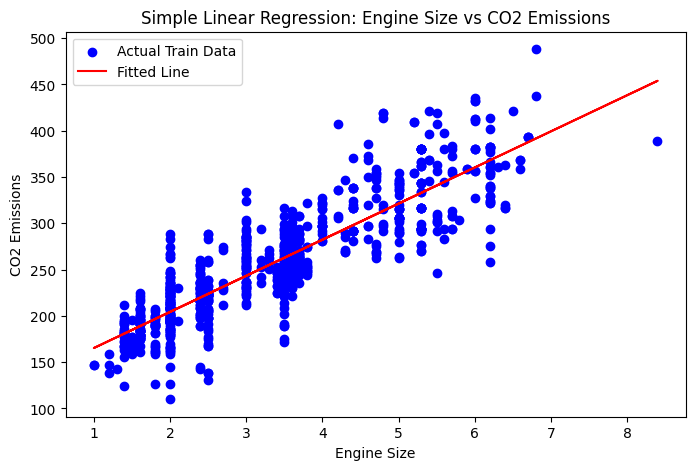



=== DẠNG 2: MULTIPLE LINEAR REGRESSION ===
Coefficients (Standardized): [ 25.27339614 -37.4381472 ]
Intercept (Standardized):    256.2907

[Trọng số quy đổi về quy mô gốc]
- Original Coefficients: [17.8581369  -5.01502179]
- Original Intercept:    329.1364

[Đánh giá Multiple Model trên tập Test]
- MAE:  14.29
- MSE:  466.11
- RMSE: 21.59
- R2-score: 0.8873


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. LOAD & CHUẨN BỊ DỮ LIỆU CHUNG
# ==========================================
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)

print("--- BẢNG DỮ LIỆU MẪU ---")
print(df[['ENGINESIZE', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']].head())
print("\n" + "="*50 + "\n")


# ==========================================
# DẠNG 1: SIMPLE LINEAR REGRESSION (1 BIẾN)
# Dự đoán CO2EMISSIONS từ ENGINESIZE
# ==========================================
print("=== DẠNG 1: SIMPLE LINEAR REGRESSION ===")

# 1. Trích xuất đặc trưng (X) và nhãn (y)
X_simple = df['ENGINESIZE'].to_numpy()
y_simple = df['CO2EMISSIONS'].to_numpy()

# 2. Chia tập Train / Test (80% / 20%)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# 3. Khởi tạo và huấn luyện mô hình (Reshape X thành 2D array)
regr_simple = linear_model.LinearRegression()
regr_simple.fit(X_train_s.reshape(-1, 1), y_train_s)

# 4. In thông số mô hình (y = a*x + b)
print(f"Hệ số góc (Coefficient): {regr_simple.coef_[0]:.4f}")
print(f"Tung độ gốc (Intercept): {regr_simple.intercept_:.4f}")

# 5. Dự đoán trên tập Test & Đánh giá
y_pred_s = regr_simple.predict(X_test_s.reshape(-1, 1))
print("\n[Đánh giá Simple Model trên tập Test]")
print(f"- MAE:  {mean_absolute_error(y_test_s, y_pred_s):.2f}")
print(f"- MSE:  {mean_squared_error(y_test_s, y_pred_s):.2f}")
print(f"- RMSE: {np.sqrt(mean_squared_error(y_test_s, y_pred_s)):.2f}")
print(f"- R2-score: {r2_score(y_test_s, y_pred_s):.4f}")

# 6. Trực quan hóa đường Hồi quy
plt.figure(figsize=(8, 5))
plt.scatter(X_train_s, y_train_s, color='blue', label='Actual Train Data')
plt.plot(X_train_s, regr_simple.coef_[0] * X_train_s + regr_simple.intercept_, '-r', label='Fitted Line')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title("Simple Linear Regression: Engine Size vs CO2 Emissions")
plt.legend()
plt.show()

print("\n" + "="*50 + "\n")


# ==========================================
# DẠNG 2: MULTIPLE LINEAR REGRESSION (ĐA BIẾN)
# Dự đoán CO2EMISSIONS từ ENGINESIZE & FUELCONSUMPTION_COMB_MPG
# ==========================================
print("=== DẠNG 2: MULTIPLE LINEAR REGRESSION ===")

# 1. Trích xuất các cột đặc trưng tốt nhất và nhãn
X_multi = df[['ENGINESIZE', 'FUELCONSUMPTION_COMB_MPG']].to_numpy()
y_multi = df[['CO2EMISSIONS']].to_numpy()

# 2. Chuẩn hóa dữ liệu đầu vào (Standardization)
std_scaler = preprocessing.StandardScaler()
X_multi_std = std_scaler.fit_transform(X_multi)

# 3. Chia tập Train / Test (80% / 20%)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi_std, y_multi, test_size=0.2, random_state=42
)

# 4. Khởi tạo và huấn luyện mô hình Đa biến
regr_multi = linear_model.LinearRegression()
regr_multi.fit(X_train_m, y_train_m)

# 5. In thông số trên không gian đã chuẩn hóa
print(f"Coefficients (Standardized): {regr_multi.coef_[0]}")
print(f"Intercept (Standardized):    {regr_multi.intercept_[0]:.4f}")

# 6. Quy đổi hệ số về không gian dữ liệu thực tế ban đầu (Un-standardization)
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)
coef_original = regr_multi.coef_[0] / std_devs_
intercept_original = regr_multi.intercept_[0] - np.sum((means_ * regr_multi.coef_[0]) / std_devs_)

print("\n[Trọng số quy đổi về quy mô gốc]")
print(f"- Original Coefficients: {coef_original}")
print(f"- Original Intercept:    {intercept_original:.4f}")

# 7. Dự đoán trên tập Test & Đánh giá
y_pred_m = regr_multi.predict(X_test_m)
print("\n[Đánh giá Multiple Model trên tập Test]")
print(f"- MAE:  {mean_absolute_error(y_test_m, y_pred_m):.2f}")
print(f"- MSE:  {mean_squared_error(y_test_m, y_pred_m):.2f}")
print(f"- RMSE: {np.sqrt(mean_squared_error(y_test_m, y_pred_m)):.2f}")
print(f"- R2-score: {r2_score(y_test_m, y_pred_m):.4f}")